In [179]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from scipy.stats import chi2_contingency
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import LabelEncoder

import warnings
warnings.filterwarnings('ignore')

1. Problem Understanding & Setup

In [180]:
train_df = pd.read_csv('../data/train.csv')
test_df = pd.read_csv('../data/test.csv')

In [181]:
train_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


The target is 1/0 (classification), and the evaluation metric used is accuracy.

2. Initial Inspection

In [182]:
#Check if the data type is correct
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [183]:
#Check the number of missing values
print(train_df.isnull().sum())

# Calculating the percentage of missing values ​​for all columns
print("Persentase Missing Value Pada Tiap Kolom")
persentase_missing = train_df.isnull().mean() * 100
print(persentase_missing)

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64
Persentase Missing Value Pada Tiap Kolom
PassengerId     0.000000
Survived        0.000000
Pclass          0.000000
Name            0.000000
Sex             0.000000
Age            19.865320
SibSp           0.000000
Parch           0.000000
Ticket          0.000000
Fare            0.000000
Cabin          77.104377
Embarked        0.224467
dtype: float64


In [184]:
#Check the number of unique values ​​in each column
train_df.nunique()

PassengerId    891
Survived         2
Pclass           3
Name           891
Sex              2
Age             88
SibSp            7
Parch            7
Ticket         681
Fare           248
Cabin          147
Embarked         3
dtype: int64

In [185]:
#Check for duplicate data
print(train_df.duplicated().sum())

0


Jumlah per kelas:
 Survived
0    549
1    342
Name: count, dtype: int64

Persentase per kelas:
 Survived
0    61.616162
1    38.383838
Name: proportion, dtype: float64


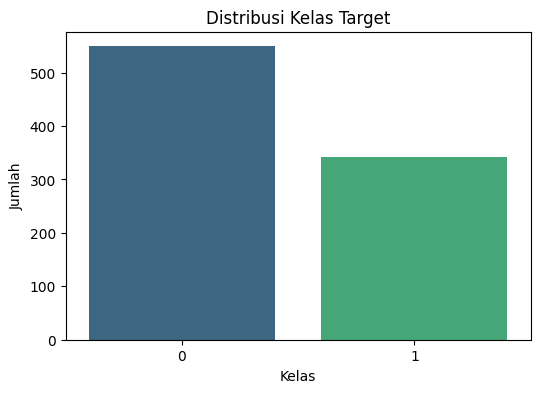

In [186]:
#Check target distribution

# 1. View the absolute count and percentage of each class
print("Jumlah per kelas:\n", train_df['Survived'].value_counts())
print("\nPersentase per kelas:\n", train_df['Survived'].value_counts(normalize=True) * 100)

# 2. Visualization with Bar Plots
plt.figure(figsize=(6, 4))
sns.countplot(x='Survived', data=train_df, hue='Survived', palette='viridis', legend=False)
plt.title('Distribusi Kelas Target')
plt.xlabel('Kelas')
plt.ylabel('Jumlah')
plt.show()

Dataset Overview

Shape: 891 rows × 12 columns
Duplicates: 0 rows
Missing values: Age (19.87%), Cabin (77.10%), Embarked (0.22%)
Did not survive: 61.6%, Survived: 38.4% — slight imbalance; accuracy remains a suitable metric.

3. Exploratory Data Analysis (EDA)

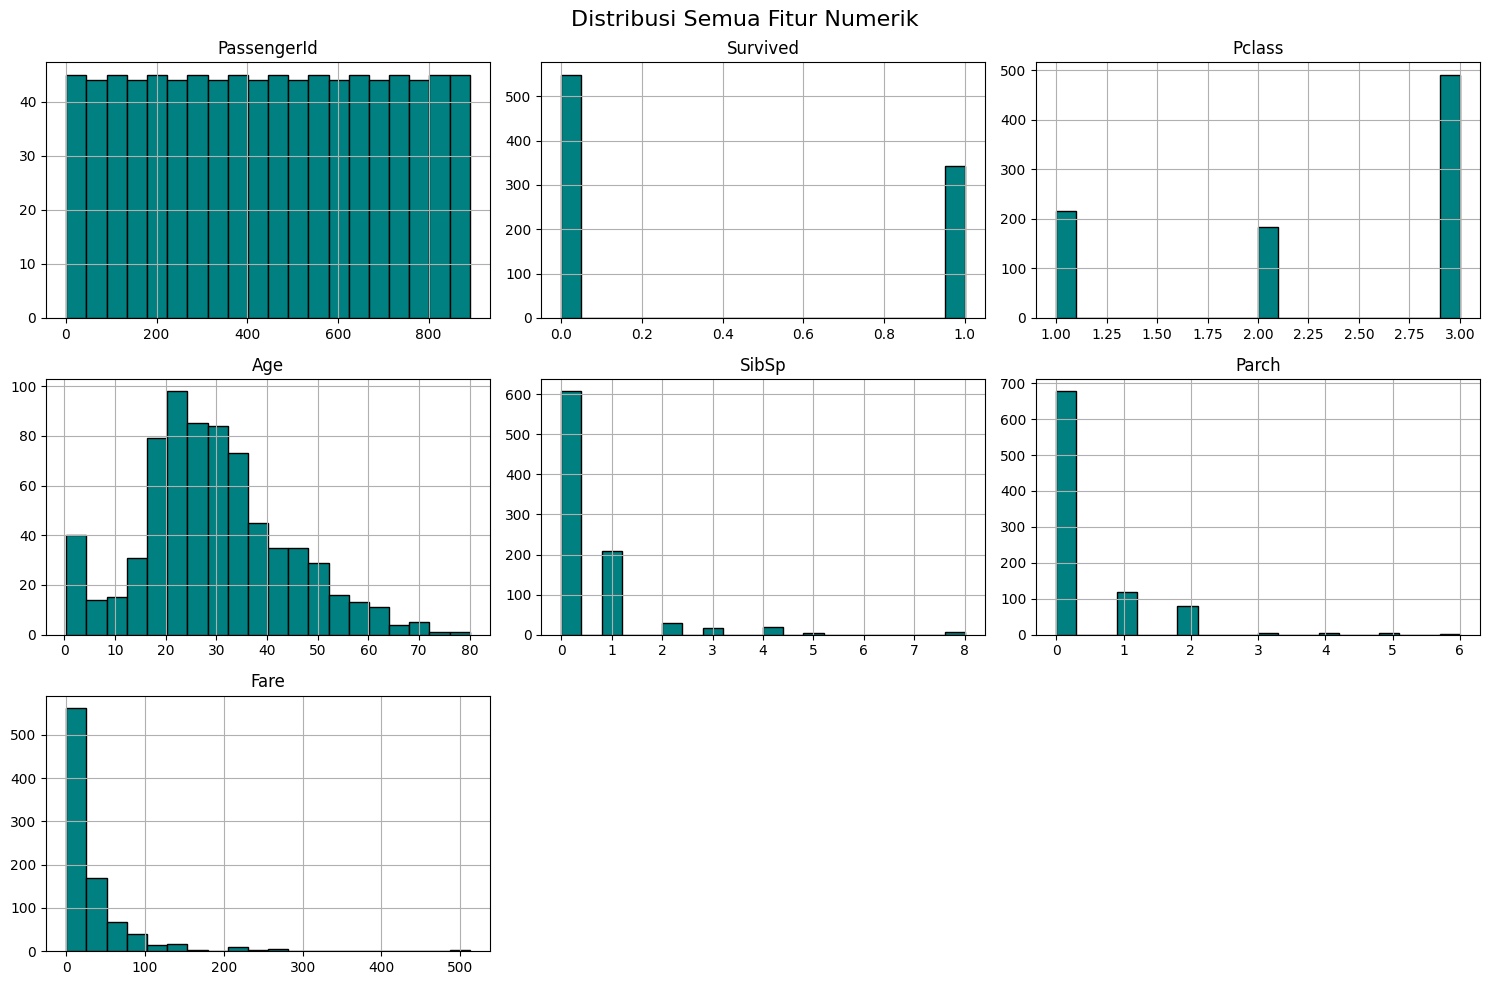

In [187]:
#Numerical Feature Distribution
train_df.hist(bins=20, figsize=(15, 10), color='teal', edgecolor='black')
plt.suptitle("Distribusi Semua Fitur Numerik", fontsize=16)
plt.tight_layout()
plt.show()

There is a skew in the Fare column (Ticket Price)

In [188]:
#Check for Outliers in Numerical Features

kolom_numerik = ['Age', 'Fare']

for kol in kolom_numerik:
    Q1 = train_df[kol].quantile(0.25)
    Q3 = train_df[kol].quantile(0.75)
    IQR = Q3 - Q1
    
    batas_bawah = Q1 - 1.5 * IQR
    batas_atas = Q3 + 1.5 * IQR
    
    jumlah_outlier = train_df[(train_df[kol] < batas_bawah) | (train_df[kol] > batas_atas)].shape[0]
    
    print(f"Fitur: {kol} - {jumlah_outlier}")

    outlier = train_df.loc[(train_df[kol] < batas_bawah) | (train_df[kol] > batas_atas), kol]
    print(outlier.sort_values(ascending=False))

Fitur: Age - 11
630    80.0
851    74.0
96     71.0
493    71.0
116    70.5
672    70.0
745    70.0
33     66.0
54     65.0
456    65.0
280    65.0
Name: Age, dtype: float64
Fitur: Fare - 116
258    512.3292
737    512.3292
679    512.3292
27     263.0000
341    263.0000
         ...   
324     69.5500
369     69.3000
641     69.3000
336     66.6000
151     66.6000
Name: Fare, Length: 116, dtype: float64


Outlier Detection (IQR method)

Age: 11 outliers (predominantly ages 65–80)
Fare: 116 outliers (including the most expensive ticket at 512.33)
Decision: Outliers not removed; considered plausible.

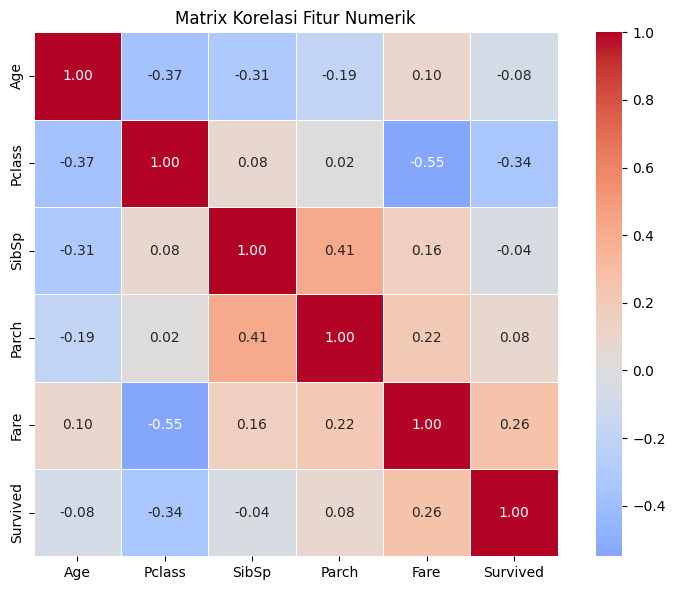

In [189]:
#Check correlation between numerical features
kolom_numerik = ['Age', 'Pclass', 'SibSp', 'Parch', 'Fare', 'Survived']
corr = train_df[kolom_numerik].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True, linewidths=0.5)
plt.title('Matrix Korelasi Fitur Numerik')
plt.tight_layout()
plt.show()

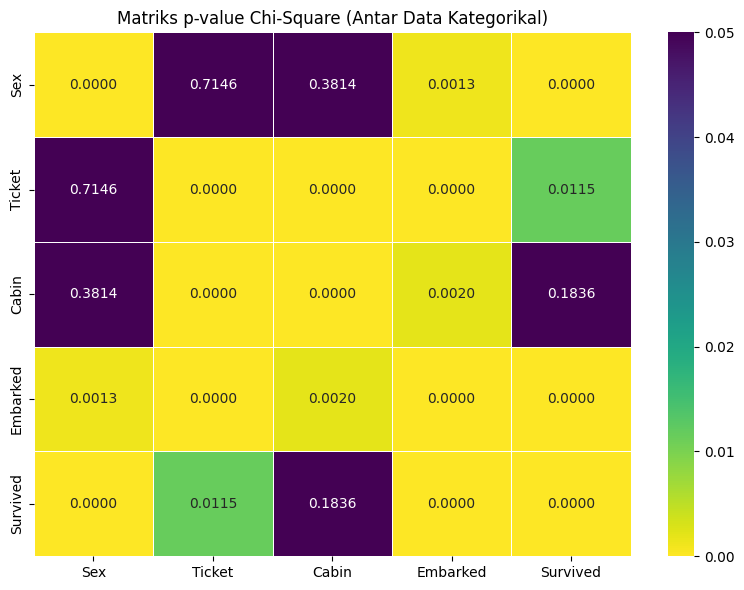

In [190]:
#Check correlation between categorical features
kolom_kategorikal = ['Sex', 'Ticket', 'Cabin', 'Embarked', 'Survived']

# 1. Prepare an empty DataFrame (matrix) to store the p-value results.
chi2_matrix = pd.DataFrame(
    np.zeros((len(kolom_kategorikal), len(kolom_kategorikal))),
    columns=kolom_kategorikal,
    index=kolom_kategorikal
)

#2. Looping process to pair each column
for col1 in kolom_kategorikal:
    for col2 in kolom_kategorikal:
        if col1 == col2:
            # The relationship of a variable with itself is necessarily 0 (highly significant).
            chi2_matrix.loc[col1, col2] = 0.0 
        else:
            # A. Create a contingency table (crosstab) between the two columns.
            crosstab = pd.crosstab(train_df[col1], train_df[col2])
            
            # B. Run the Chi-Square test
            # chi2_contingency returns 4 values; we only need the p-value (the second value)
            _, p_value, _, _ = chi2_contingency(crosstab)
            
            # C. Enter the resulting p-value into the matrix
            chi2_matrix.loc[col1, col2] = p_value

# 3. Creating a heatmap from the loop results
plt.figure(figsize=(8, 6))

# Using cmap='viridis_r' so that small p-values ​​(indicating a strong relationship) appear dark/distinct
# The maximum limit (vmax) is set to 0.05, as this is the standard significance threshold
sns.heatmap(chi2_matrix, annot=True, fmt='.4f', cmap='viridis_r', vmin=0, vmax=0.05, linewidths=0.5)

plt.title('Matriks p-value Chi-Square (Antar Data Kategorikal)')
plt.tight_layout()
plt.show()

Numerical: Pclass - Survived (-0.34), Fare - Survived (0.26), Pclass - Fare (-0.55)

Categorical (Chi-Square): Sex is the most significant (p=0.0000), Embarked & Ticket are significant, Cabin is not significant (p=0.1836)

Key EDA Findings

1. Mild class imbalance: 61.6% did not survive vs. 38.4% survived
2. Sex is the strongest categorical predictor (Chi-Square p ≈ 0.0000)
3. Pclass shows the strongest negative correlation with Survived (r ≈ -0.34) and a strong correlation with Fare (r ≈ -0.55), indicating multicollinearity
4. Cabin is not significant regarding Survived (p = 0.18) and has 77% missing values ​​= dropped
5. Fare is right-skewed = handled via binning (qcut into 5 categories)
6. Age and Fare outliers are domain-plausible (elderly passengers, VIP tickets) = not removed
7. Age, SibSp, and Parch show weak individual correlations with Survived = prompted the creation of combined features (Family_Size, Family_Survival)

4. Data Preprocessing

In [191]:
#Create a 'title' column to extract the word ending with a period (.) from the 'name' column.
train_df['Title'] = train_df['Name']
for name_string in train_df['Name']:
    train_df['Title'] = train_df['Name'].str.extract('([A-Za-z]+)\.', expand=True)

#Replacing rarely occurring noble titles to ensure the median age is accurate
mapping = {'Mlle': 'Miss', 'Major': 'Mr', 'Col': 'Mr', 'Sir': 'Mr', 'Don': 'Mr', 'Mme': 'Miss',
          'Jonkheer': 'Mr', 'Lady': 'Mrs', 'Capt': 'Mr', 'Countess': 'Mrs', 'Ms': 'Miss', 'Dona': 'Mrs'}
train_df.replace({'Title': mapping}, inplace=True)

#Filling in missing Age values ​​with the provided median age
titles = ['Dr', 'Master', 'Miss', 'Mr', 'Mrs', 'Rev']
for title in titles:
    age_to_impute = train_df.groupby('Title')['Age'].median()[title]
    train_df.loc[(train_df['Age'].isnull()) & (train_df['Title'] == title), 'Age'] = age_to_impute


In [192]:
#Preparing test data to avoid data leakage.
age_median_by_title = train_df.groupby('Title')['Age'].median()
fare_median = train_df['Fare'].median()

fare_bins = pd.qcut(train_df['Fare'], 5, retbins=True)[1]  
fare_bins[0], fare_bins[-1] = -np.inf, np.inf              
age_bins = pd.qcut(train_df['Age'], 4, retbins=True)[1]
age_bins[0], age_bins[-1] = -np.inf, np.inf

fare_label = LabelEncoder().fit(pd.cut(train_df['Fare'], bins=fare_bins))
age_label = LabelEncoder().fit(pd.cut(train_df['Age'], bins=age_bins))

#Drop the helper column
train_df.drop('Title', axis = 1, inplace = True)

5. Feature Engineering

In [193]:
#Combining the Parch and SibSp columns for family size
train_df['Family_Size'] = train_df['Parch'] + train_df['SibSp']

In [194]:
#Creating the last_name column and filling missing values ​​in the fare column using the mean
train_df['Last_Name'] = train_df['Name'].apply(lambda x: str.split(x, ",")[0])
train_df['Fare'].fillna(train_df['Fare'].median(), inplace=True)

DEFAULT_SURVIVAL_VALUE = 0.5
train_df['Family_Survival'] = DEFAULT_SURVIVAL_VALUE

#Grouping passengers with the same last name and ticket price
for grp, grp_df in train_df[['Survived','Name', 'Last_Name', 'Fare', 'Ticket', 'PassengerId',
                           'SibSp', 'Parch', 'Age', 'Cabin']].groupby(['Last_Name', 'Fare']):

#If any family member survives, then family survival = 1; if none survive, then 0.
    if (len(grp_df) != 1):
        for ind, row in grp_df.iterrows():
            smax = grp_df.drop(ind)['Survived'].max()
            smin = grp_df.drop(ind)['Survived'].min()
            passID = row['PassengerId']
            if (smax == 1.0):
                train_df.loc[train_df['PassengerId'] == passID, 'Family_Survival'] = 1
            elif (smin==0.0):
                train_df.loc[train_df['PassengerId'] == passID, 'Family_Survival'] = 0

In [195]:
#Grouping passengers based on identical tickets
for _, grp_df in train_df.groupby('Ticket'):

#If there is a surviving passenger with an identical ticket, then family survival = 1; otherwise, 0.
    if (len(grp_df) != 1):
        for ind, row in grp_df.iterrows():
            if (row['Family_Survival'] == 0) | (row['Family_Survival']== 0.5):
                smax = grp_df.drop(ind)['Survived'].max()
                smin = grp_df.drop(ind)['Survived'].min()
                passID = row['PassengerId']
                if (smax == 1.0):
                    train_df.loc[train_df['PassengerId'] == passID, 'Family_Survival'] = 1
                elif (smin==0.0):
                    train_df.loc[train_df['PassengerId'] == passID, 'Family_Survival'] = 0

In [196]:
#Splitting the Fare column into 5 parts
train_df['FareBin'] = pd.qcut(train_df['Fare'], 5)

#Transform into numbers using a label encoder and store the result in a new column
label = LabelEncoder()
train_df['FareBin_Code'] = label.fit_transform(train_df['FareBin'])

In [197]:
#Splitting the Age column into 4 parts
train_df['AgeBin'] = pd.qcut(train_df['Age'], 4)

#Transform into numbers using a label encoder and store the result in a new column
label = LabelEncoder()
train_df['AgeBin_Code'] = label.fit_transform(train_df['AgeBin'])


In [198]:
#Converting 'male' and 'female' data into binary numbers
train_df['Sex'].replace(['male','female'],[0,1],inplace=True)

#Drop columns that are no longer needed
train_df.drop(['Name', 'PassengerId', 'SibSp', 'Parch', 'Ticket', 'Cabin',
               'Embarked', 'Age', 'FareBin', 'AgeBin'], axis = 1, inplace = True)

In [199]:
train_df.head()

,Survived,Pclass,Sex,Fare,Family_Size,Last_Name,Family_Survival,FareBin_Code,AgeBin_Code
0,0,3,0,7.2500,1,Braund,0.5,0,1
1,1,1,1,71.2833,1,Cumings,0.5,4,3
2,1,3,1,7.9250,0,Heikkinen,0.5,1,1
3,1,1,1,53.1000,1,Futrelle,0.0,4,2
4,0,3,0,8.0500,0,Allen,0.5,1,2


6. Transform Data Test

In [200]:
#Create a 'Title' column for entering academic degrees or honorifics.
test_df['Title'] = test_df['Name']
for name_string in test_df['Name']:
    test_df['Title'] = test_df['Name'].str.extract('([A-Za-z]+)\.', expand=True)

#Mapping so that there are not too many titles that have little value
mapping = {'Mlle': 'Miss', 'Major': 'Mr', 'Col': 'Mr', 'Sir': 'Mr', 'Don': 'Mr', 'Mme': 'Miss',
          'Jonkheer': 'Mr', 'Lady': 'Mrs', 'Capt': 'Mr', 'Countess': 'Mrs', 'Ms': 'Miss', 'Dona': 'Mrs'}
test_df.replace({'Title': mapping}, inplace=True)
titles = ['Dr', 'Master', 'Miss', 'Mr', 'Mrs', 'Rev']

#Imputing missing values ​​in the 'age' column using the median of the previously determined titles.
for title in titles:
    test_df.loc[(test_df['Age'].isnull()) & (test_df['Title'] == title), 'Age'] = age_median_by_title[title]

#Drop the title column
test_df.drop('Title', axis = 1, inplace = True)



#Create a new 'family size' column containing the number of family members for each passenger.
test_df['Family_Size'] = test_df['Parch'] + test_df['SibSp']


#Creating a 'last name' column to identify family groups
test_df['Last_Name'] = test_df['Name'].apply(lambda x: str.split(x, ",")[0])


test_df['Family_Survival'] = 0.5  

#Create a reference group from the training data that already contains 'Survived' information.
train_groups = train_df.groupby(['Last_Name', 'Fare'])

#Check if passengers in the test data share similarities with passengers in the training data.
for ind, row in test_df.iterrows():
    kunci_keluarga = (row['Last_Name'], row['Fare'])
    
    # Check if the family key of this test passenger exists in the training data
    if kunci_keluarga in train_groups.groups:
        # Extract their family data present in the training set
        anggota_keluarga_di_train = train_groups.get_group(kunci_keluarga)
        
        smax = anggota_keluarga_di_train['Survived'].max()
        smin = anggota_keluarga_di_train['Survived'].min()
        
        # Assign values ​​based on the training data
        if smax == 1.0:
            test_df.loc[ind, 'Family_Survival'] = 1.0
        elif smin == 0.0:
            test_df.loc[ind, 'Family_Survival'] = 0.0


#Fill missing Fare values ​​with the median
test_df['Fare'].fillna(fare_median, inplace=True)

#Transform using label encoder
test_df['FareBin_Code'] = fare_label.transform(pd.cut(test_df['Fare'], bins=fare_bins))

#Drop because it's no longer needed (already have a new one)
test_df.drop(['Fare'], axis=1, inplace=True)

#Convert the Age column into 4 categories and Transform using label encoder
test_df['AgeBin_Code'] = age_label.transform(pd.cut(test_df['Age'], bins=age_bins))

#Drop column in train
train_df.drop(['Last_Name', 'Fare'], axis=1, inplace=True)

#Transform the 'sex' column into binary
test_df['Sex'].replace(['male','female'],[0,1],inplace=True)

#Drop columns from the test data
test_df.drop(['Name', 'PassengerId', 'SibSp', 'Parch', 'Ticket', 'Cabin',
               'Embarked', 'Age', 'Last_Name'], axis = 1, inplace = True)

In [201]:
train_df.nunique()

Survived           2
Pclass             3
Sex                2
Family_Size        9
Family_Survival    3
FareBin_Code       5
AgeBin_Code        4
dtype: int64

In [202]:
train_df.head()

,Survived,Pclass,Sex,Family_Size,Family_Survival,FareBin_Code,AgeBin_Code
0,0,3,0,1,0.5,0,1
1,1,1,1,1,0.5,4,3
2,1,3,1,0,0.5,1,1
3,1,1,1,1,0.0,4,2
4,0,3,0,0,0.5,1,2


In [203]:
test_df.head()

,Pclass,Sex,Family_Size,Family_Survival,FareBin_Code,AgeBin_Code
0,3,0,0,0.5,0,2
1,3,1,1,0.5,0,3
2,2,0,0,0.5,1,3
3,3,0,0,0.5,1,1
4,3,1,2,1.0,2,1


7. Modeling

In [204]:
#Separate the target column (Survived) so a test set can be created.
X_train = train_df.drop('Survived', axis=1)
y_train = train_df['Survived']
X_test = test_df.copy()

In [205]:
#Standardization to ensure uniform value scales across all features (mean = 0, std = 1)
std_scaler = StandardScaler()
X_train = std_scaler.fit_transform(X_train)
X_test = std_scaler.transform(X_test)

In [206]:
#Finding the model with the best hyperparameter combination for the KNN model

n_neighbors = [6,7,8,9,10,11,12,14,16,18,20,22]
algorithm = ['auto']
weights = ['uniform', 'distance']
leaf_size = list(range(1,50,5))
hyperparams = {'algorithm': algorithm, 'weights': weights, 'leaf_size': leaf_size, 
               'n_neighbors': n_neighbors}
gd=GridSearchCV(estimator = KNeighborsClassifier(), param_grid = hyperparams, verbose=True, 
                cv=10, scoring = "roc_auc")
gd.fit(X_train, y_train)
print(gd.best_score_)
print(gd.best_estimator_)

Fitting 10 folds for each of 240 candidates, totalling 2400 fits
0.881856124267889
KNeighborsClassifier(leaf_size=26, n_neighbors=14)


In [207]:
#Selecting the best hyperparameter combination
model_final = gd.best_estimator_

#Predict
y_pred = model_final.predict(X_test)


In [208]:
temp = pd.DataFrame(pd.read_csv("../data/test.csv")['PassengerId'])
temp['Survived'] = y_pred
temp.to_csv("../output/titanic.csv", index = False)

In [209]:
preprocessing_params = {
    'age_median_by_title': age_median_by_title,
    'fare_median': fare_median,
    'fare_bins': fare_bins,
    'age_bins': age_bins,
    'fare_label': fare_label,
    'age_label': age_label,
}

joblib.dump(preprocessing_params, '../models/preprocessing_params.pkl')

['../models/preprocessing_params.pkl']

In [210]:
joblib.dump(model_final, '../models/knn_titanic_model.pkl')
joblib.dump(std_scaler, '../models/scaler.pkl')
joblib.dump(preprocessing_params, '../models/preprocessing_params.pkl')

['../models/preprocessing_params.pkl']